## Train A Test B

Category distribution:
0    10731
5     8131
2     4103
4     2904
3       85
6       36
7       14
1        5
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.50      0.62      0.55     20905
      Button       0.00      0.00      0.00       116
 Coordinator       0.62      0.24      0.34      6224
        Door       0.40      0.01      0.03       280
      Motion       0.40      0.69      0.50      2004
      Socket       0.45      0.40      0.42     17789
 Temperature       0.00      0.00      0.00       159
   Vibration       0.00      0.00      0.00        40

    accuracy                           0.48     47517
   macro avg       0.30      0.24      0.23     47517
weighted avg       0.49      0.48      0.47     47517



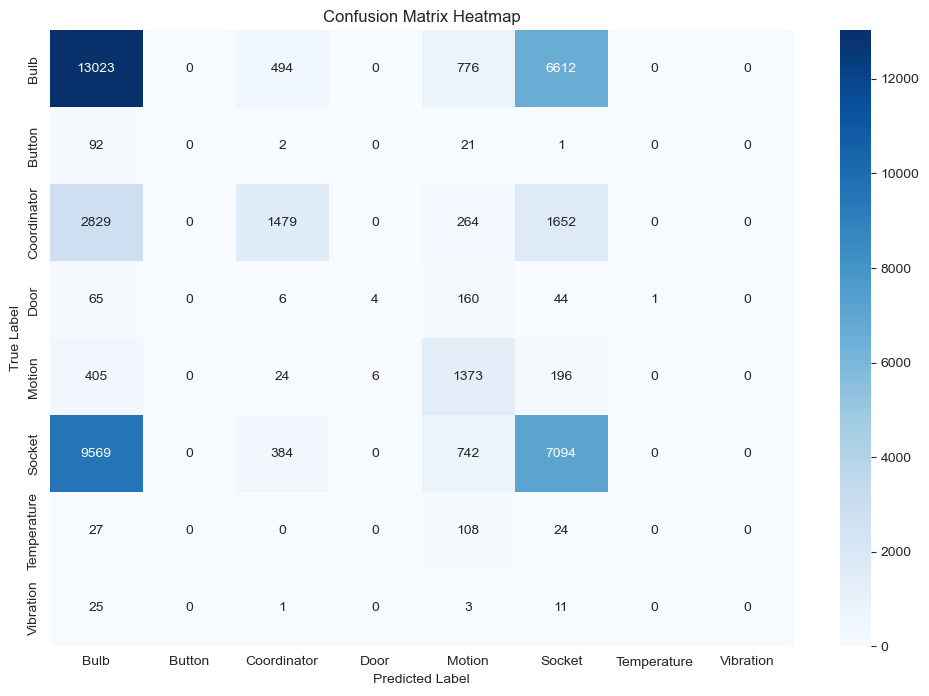

In [1]:
# Classification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Sequence_Data/Sequence_Data_Topology_A_fix_packets_known.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type"])
y_train = train_data["Device Type"]

y_train = y_train.astype('category')
categories = y_train.cat.categories 
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path = "./Sequence_Data/Sequence_Data_Topology_B_fix_packets_known.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type"])
y_test = test_data["Device Type"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))

target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)
report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

Category distribution:
5     4103
12    2786
6     2764
10    2534
13    2068
11    1969
15    1943
16    1903
14    1691
9     1396
7     1330
8     1264
20      43
3       43
17      43
21      36
19      32
18      23
4       14
1       10
2        9
0        5
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.00      0.00      0.00       116
        Aqara Door 1       0.00      0.00      0.00        52
        Aqara Door 2       0.00      0.00      0.00        12
        Aqara Motion       0.14      0.02      0.03       120
     Aqara Vibration       0.00      0.00      0.00        40
         Coordinator       0.29      0.36      0.32      6224
       Ledvance Bulb       0.23      0.21      0.22      5202
Ledvance Smart+ Plug       0.08      0.11      0.09      2702
    Ledvance Z3 Plug       0.11      0.07      0.08      3648
           Moes Bulb       0.15      0.10      0.12      3417
      Philips Lamp 1      

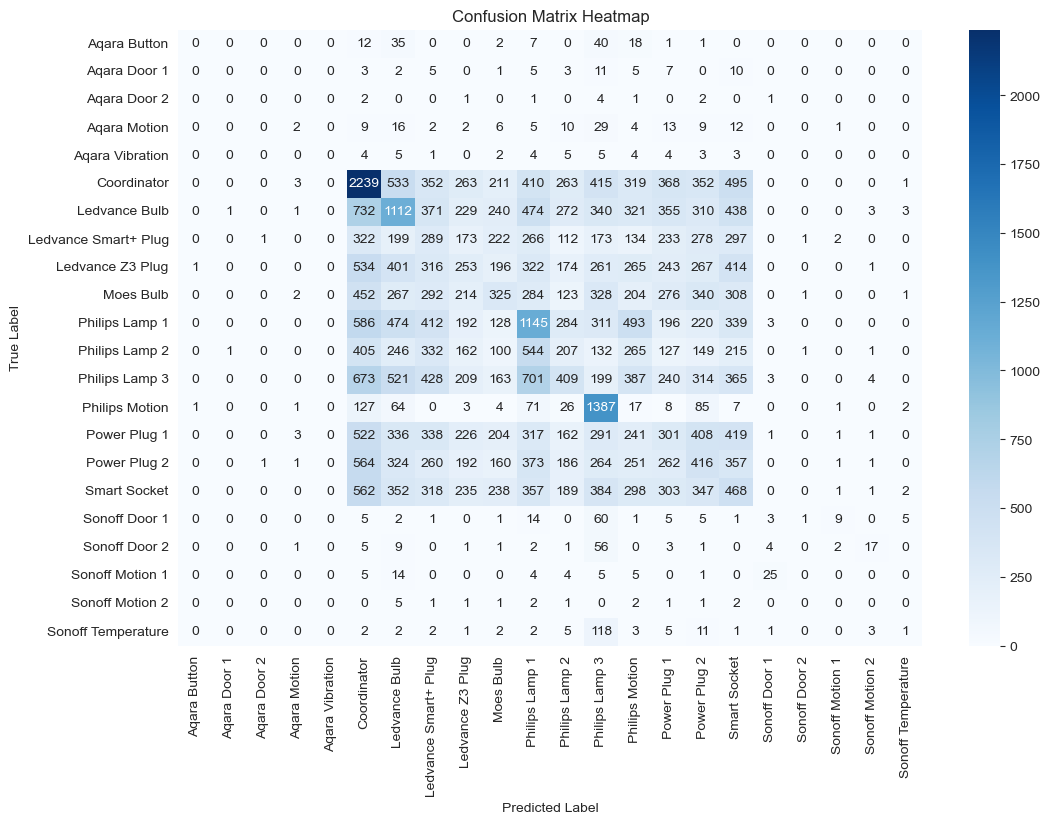

In [2]:
# Identification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Sequence_Data/Sequence_Data_Topology_A_fix_packets_known.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type"])
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories 
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path = "./Sequence_Data/Sequence_Data_Topology_B_fix_packets_known.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type"])
y_test = test_data["Device Name"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))

target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)
report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

Category distribution:
0    13642
2    12859
5    12221
4     4059
3      238
6       89
7       39
1       30
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.44      0.57      0.50     26861
      Button       0.00      0.00      0.00       119
 Coordinator       0.40      0.51      0.45     18696
        Door       0.23      0.03      0.06       288
      Motion       0.36      0.48      0.41      2038
      Socket       0.40      0.17      0.24     23663
 Temperature       0.90      0.08      0.15       230
   Vibration       0.00      0.00      0.00        25

    accuracy                           0.42     71920
   macro avg       0.34      0.23      0.23     71920
weighted avg       0.41      0.42      0.39     71920



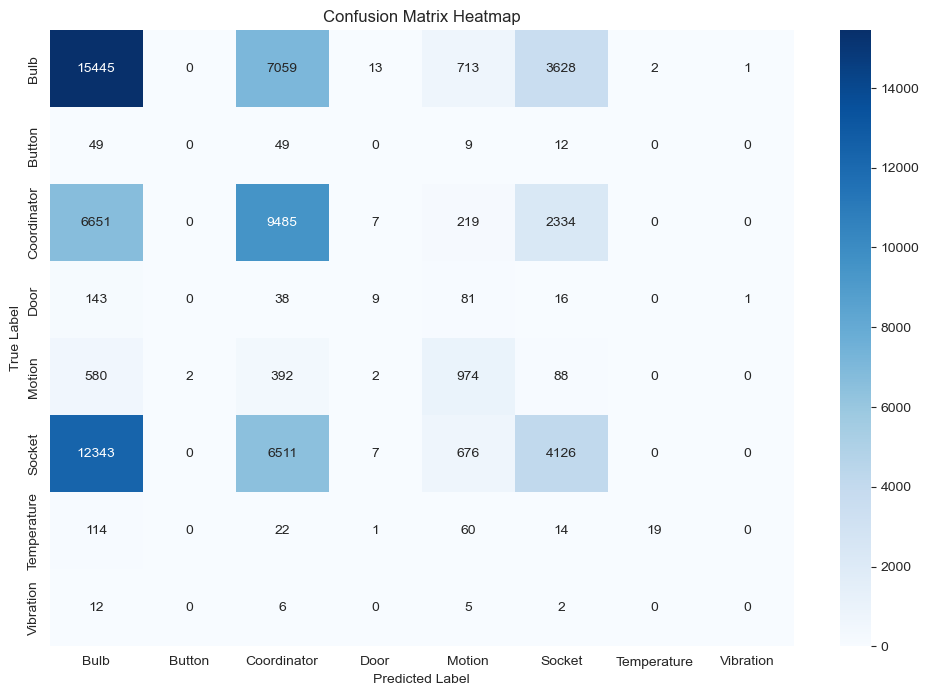

In [3]:
# Classification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Sequence_Data/Sequence_Data_Topology_A_fix_durations_known.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type"])
y_train = train_data["Device Type"]

y_train = y_train.astype('category')
categories = y_train.cat.categories 
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path = "./Sequence_Data/Sequence_Data_Topology_B_fix_durations_known.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type"])
y_test = test_data["Device Type"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))

target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)
report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

Category distribution:
5     12859
12     3941
16     3722
6      3715
10     3352
15     2967
14     2919
11     2789
13     2319
9      1467
7      1323
8      1290
2       132
21       89
3        50
1        44
4        39
20       36
19       32
17       31
18       31
0        30
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.00      0.00      0.00       119
        Aqara Door 1       0.00      0.00      0.00        35
        Aqara Door 2       0.11      0.09      0.10        44
        Aqara Motion       0.00      0.00      0.00       120
     Aqara Vibration       0.00      0.00      0.00        25
         Coordinator       0.32      0.80      0.45     18696
       Ledvance Bulb       0.17      0.07      0.10      8521
Ledvance Smart+ Plug       0.07      0.08      0.08      2575
    Ledvance Z3 Plug       0.11      0.04      0.06      3577
           Moes Bulb       0.11      0.03      0.05      3349
    

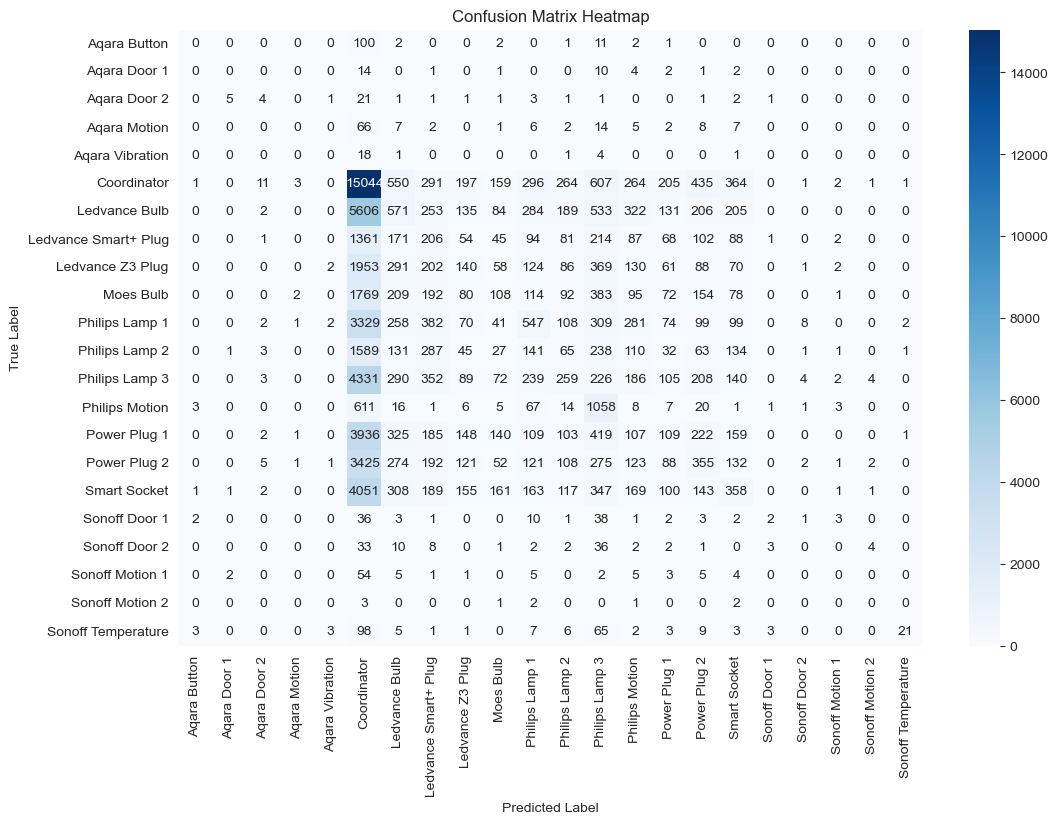

In [4]:
# Identification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Sequence_Data/Sequence_Data_Topology_A_fix_durations_known.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type"])
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories 
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path = "./Sequence_Data/Sequence_Data_Topology_B_fix_durations_known.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type"])
y_test = test_data["Device Name"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))

target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)
report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

## Train B Test A

Category distribution:
0    20905
5    17789
2     6224
4     2004
3      280
6      159
1      116
7       40
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.49      0.69      0.57     10731
      Button       0.00      0.00      0.00         5
 Coordinator       0.65      0.37      0.47      4103
        Door       0.09      0.11      0.10        85
      Motion       0.75      0.28      0.40      2904
      Socket       0.44      0.40      0.42      8131
 Temperature       0.00      0.00      0.00        36
   Vibration       0.00      0.00      0.00        14

    accuracy                           0.50     26009
   macro avg       0.30      0.23      0.25     26009
weighted avg       0.53      0.50      0.49     26009



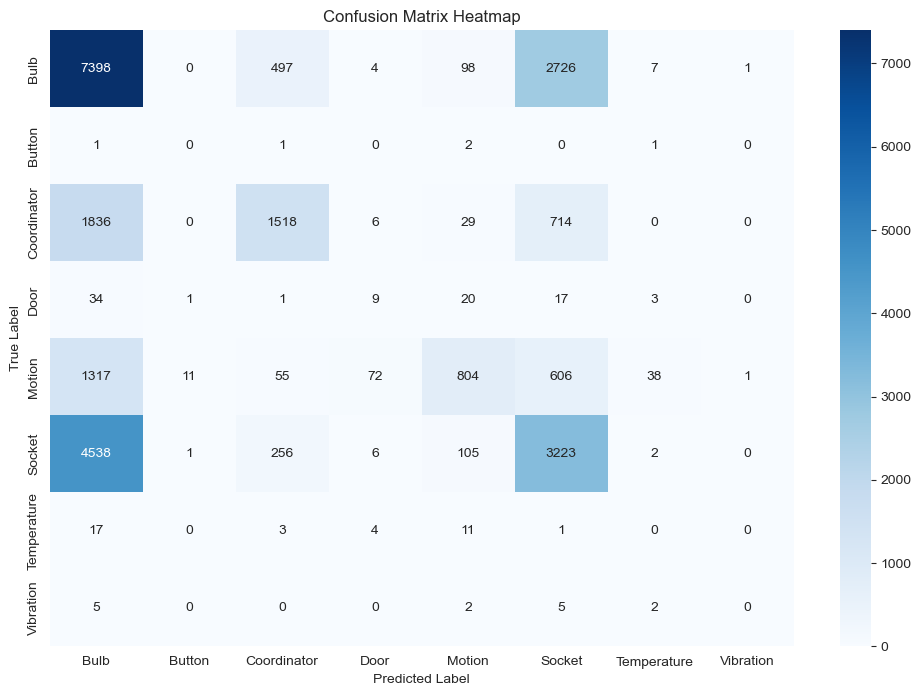

In [5]:
# Classification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Sequence_Data/Sequence_Data_Topology_B_fix_packets_known.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type"])
y_train = train_data["Device Type"]

y_train = y_train.astype('category')
categories = y_train.cat.categories 
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path = "./Sequence_Data/Sequence_Data_Topology_A_fix_packets_known.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type"])
y_test = test_data["Device Type"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))

target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)
report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

Category distribution:
5     6224
6     5202
10    4783
12    4616
16    4055
14    3771
8     3648
15    3613
9     3417
11    2887
7     2702
13    1804
21     159
3      120
0      116
17     113
18     103
19      63
1       52
4       40
20      17
2       12
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.00      0.00      0.00         5
        Aqara Door 1       0.00      0.00      0.00        10
        Aqara Door 2       0.00      0.00      0.00         9
        Aqara Motion       0.03      0.02      0.03        43
     Aqara Vibration       0.00      0.00      0.00        14
         Coordinator       0.39      0.54      0.45      4103
       Ledvance Bulb       0.27      0.31      0.29      2764
Ledvance Smart+ Plug       0.07      0.06      0.06      1330
    Ledvance Z3 Plug       0.07      0.07      0.07      1264
           Moes Bulb       0.15      0.15      0.15      1396
      Philips Lamp 1      

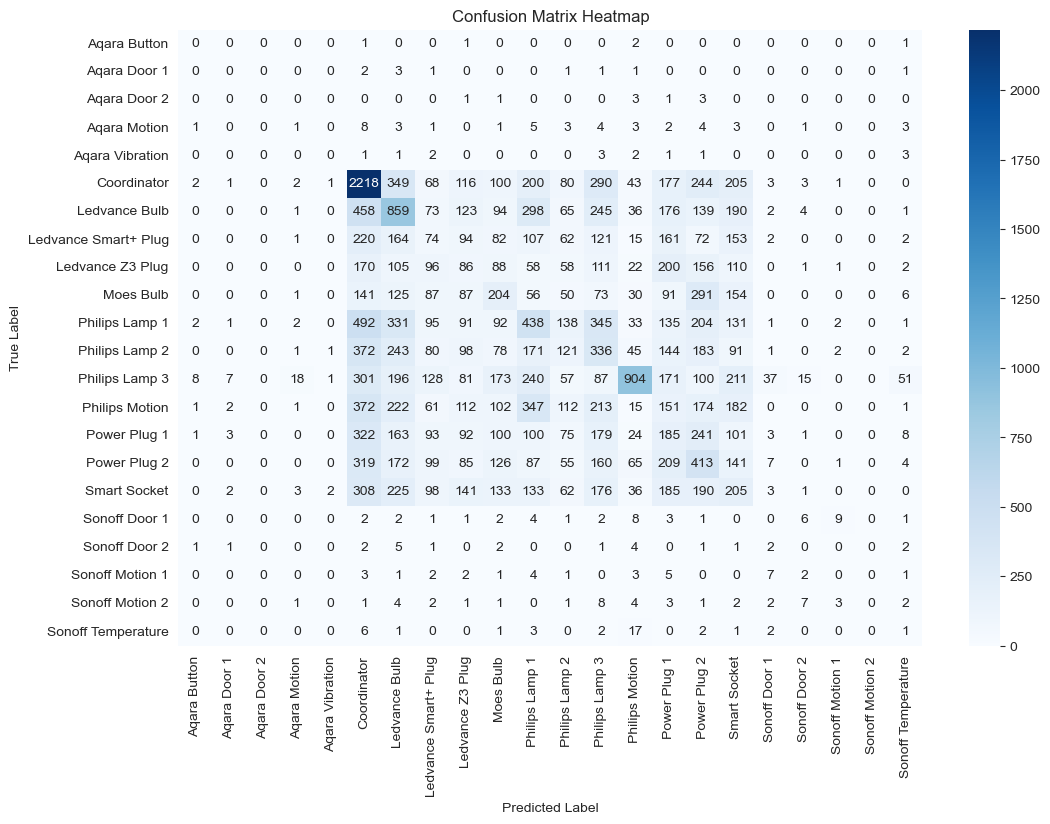

In [6]:
# Identification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Sequence_Data/Sequence_Data_Topology_B_fix_packets_known.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type"])
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories 
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path = "./Sequence_Data/Sequence_Data_Topology_A_fix_packets_known.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type"])
y_test = test_data["Device Name"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))

target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)
report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

Category distribution:
0    26861
5    23663
2    18696
4     2038
3      288
6      230
1      119
7       25
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.38      0.59      0.46     13642
      Button       0.00      0.00      0.00        30
 Coordinator       0.46      0.49      0.48     12859
        Door       0.17      0.08      0.11       238
      Motion       0.87      0.35      0.50      4059
      Socket       0.37      0.21      0.27     12221
 Temperature       0.26      0.18      0.21        89
   Vibration       0.00      0.00      0.00        39

    accuracy                           0.42     43177
   macro avg       0.31      0.24      0.25     43177
weighted avg       0.45      0.42      0.41     43177



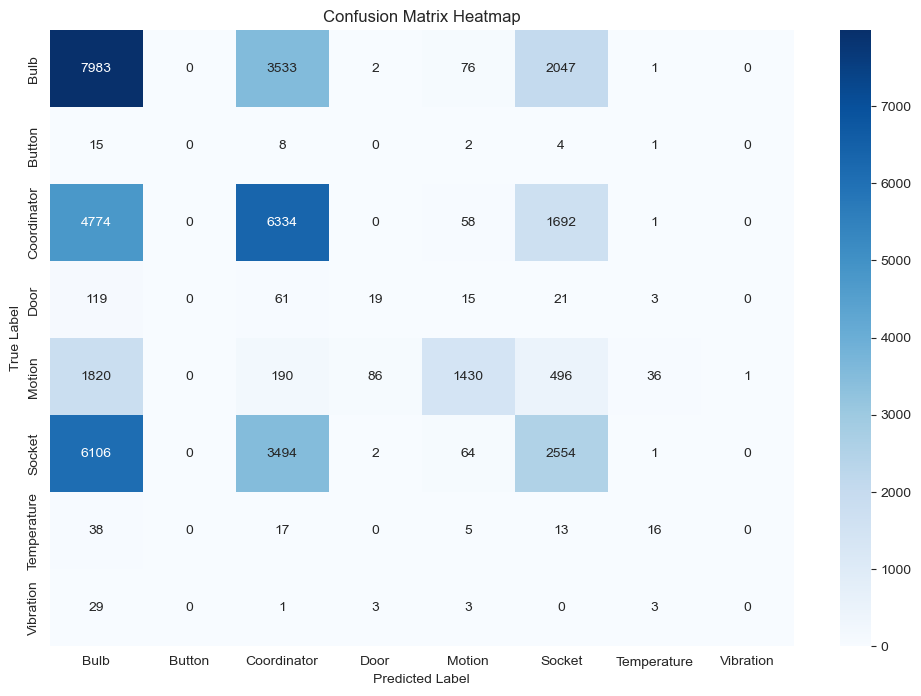

In [7]:
# Classification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Sequence_Data/Sequence_Data_Topology_B_fix_durations_known.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type"])
y_train = train_data["Device Type"]

y_train = y_train.astype('category')
categories = y_train.cat.categories 
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path = "./Sequence_Data/Sequence_Data_Topology_A_fix_durations_known.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type"])
y_test = test_data["Device Type"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))

target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)
report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

Category distribution:
5     6224
6     5202
10    4783
12    4616
16    4055
14    3771
8     3648
15    3613
9     3417
11    2887
7     2702
13    1804
21     159
3      120
0      116
17     113
18     103
19      63
1       52
4       40
20      17
2       12
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.00      0.00      0.00         5
        Aqara Door 1       0.00      0.00      0.00        10
        Aqara Door 2       0.00      0.00      0.00         9
        Aqara Motion       0.03      0.02      0.03        43
     Aqara Vibration       0.00      0.00      0.00        14
         Coordinator       0.39      0.54      0.45      4103
       Ledvance Bulb       0.27      0.31      0.29      2764
Ledvance Smart+ Plug       0.07      0.06      0.06      1330
    Ledvance Z3 Plug       0.07      0.07      0.07      1264
           Moes Bulb       0.15      0.15      0.15      1396
      Philips Lamp 1      

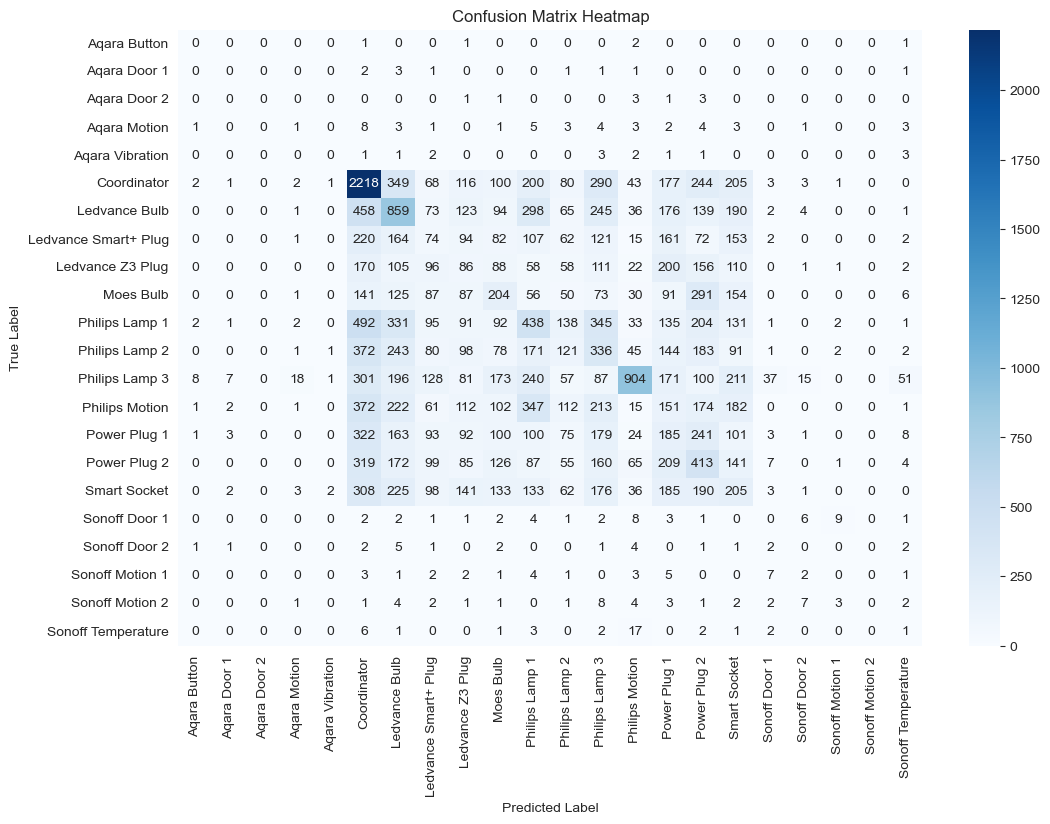

In [9]:
# Identification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Sequence_Data/Sequence_Data_Topology_B_fix_packets_known.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type"])
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories 
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path = "./Sequence_Data/Sequence_Data_Topology_A_fix_packets_known.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type"])
y_test = test_data["Device Name"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))

target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)
report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()